# Selecting Extremely Metal Poor Candidates from DESI DR1

I will apply here what I've learned in the exploration notebooks (e.g., `emfit-vac.ipynb`) to make a selection of EMP candidates.

- Do not limit by NII6583 S/N. Upper limits are useful. Better do a limit on Hb because I will need it to weed out bad measurements
- Ha measurements seem to be off very frequently in the regime of interest. One way to weed them out is to enforce Ha/Hb close to 2.86. A limit of <10 seems to be effective.


In [1]:
import os

import fitsio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table


In [2]:
columns_to_read = [
    "TARGETID",
    "TARGET_RA",
    "TARGET_DEC",
    "Z",
    "HB_N_FLUX",
    "HB_N_FLUX_ERR",
    "OIII5007_FLUX",
    "OIII5007_FLUX_ERR",
    "HA_N_FLUX",
    "HA_N_FLUX_ERR",
    "NII6583_FLUX",
    "NII6583_FLUX_ERR",
]

emfit_fname = "/mnt/DATA/survey-oficial-releases/DESI/VAC/emfit-dr1-v2.3.1.fits"

data = fitsio.read(emfit_fname, ext=1, columns=columns_to_read)

# The following is necessary to avoid and endianness problem
emfit = pd.DataFrame(
    {
        col: np.asarray(data[col], dtype=data[col].dtype.newbyteorder("<"))
        for col in data.dtype.names
    }
)

In [3]:
selection = emfit.query(
    "HB_N_FLUX / HB_N_FLUX_ERR > 3 "
    "and Z < 0.3 "
    "and OIII5007_FLUX > 0 "
    "and HA_N_FLUX > 0 "
    "and HA_N_FLUX / HB_N_FLUX < 10 "
    "and TARGET_DEC < 10"
).copy()

In [4]:
# selection["R3"] = np.log10(selection["HA_N_FLUX"] / selection["HB_N_FLUX"])  # mistake!
selection["R3"] = np.log10(selection["OIII5007_FLUX"] / selection["HB_N_FLUX"])

selection["NII_detected"] = (
    selection["NII6583_FLUX"] / selection["NII6583_FLUX_ERR"] > 3
)
selection["N2"] = np.log10(selection["NII6583_FLUX"] / selection["HA_N_FLUX"])
selection["N2_uplim"] = np.log10(
    3 * selection["NII6583_FLUX_ERR"] / selection["HA_N_FLUX"]
)
selection["N2_distilled"] = np.nan
selection.loc[selection["NII_detected"], "N2_distilled"] = selection.loc[
    selection["NII_detected"], "N2"
]
selection.loc[~selection["NII_detected"], "N2_distilled"] = selection.loc[
    ~selection["NII_detected"], "N2_uplim"
]

/mnt/Users/tino/research/desi-selection-exploration/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/Users/tino/research/desi-selection-exploration/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
mask = (selection["N2_distilled"] < -1.5) & (selection["R3"] < 0.55)
print(f"Selected {np.sum(mask)} EMP candidates")

Selected 31146 EMP candidates


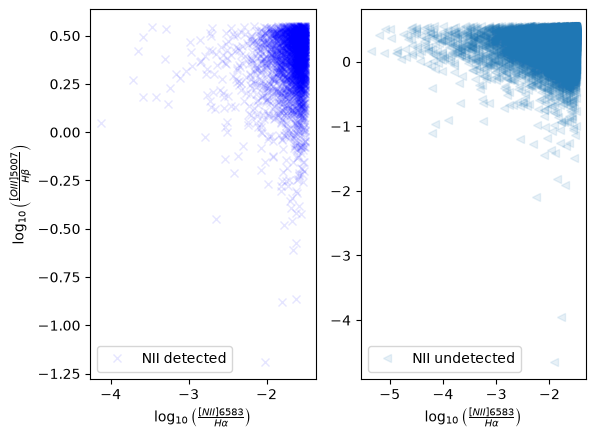

In [6]:
fig, axes = plt.subplots(1, 2)
axes[0].plot(
    selection[mask].loc[selection["NII_detected"], "N2_distilled"],
    selection[mask].loc[selection["NII_detected"], "R3"],
    "x",
    color="blue",
    alpha=0.1,
    label="NII detected",
)

axes[1].plot(
    selection[mask].loc[~selection["NII_detected"], "N2_distilled"],
    selection[mask].loc[~selection["NII_detected"], "R3"],
    "<",
    color="tab:blue",
    alpha=0.1,
    label="NII undetected",
)

axes[0].set_xlabel(r"$\log_{10} \left( \frac{[NII] 6583}{H\alpha} \right)$")
axes[1].set_xlabel(r"$\log_{10} \left( \frac{[NII] 6583}{H\alpha} \right)$")
axes[0].set_ylabel(r"$\log_{10} \left( \frac{[OIII] 5007}{H\beta} \right)$")
axes[0].legend()
axes[1].legend()

## Saving the spectra to make my own measurements

*The part about saving the spectra was moved to a script: `src/00-download-emp-sample.py`.*

In [7]:
Table.from_pandas(selection[mask]).write("../data/emp-candidates-v261018.fits", overwrite=True)

## Comparison with my measurements

I downloaded the spectra for the selected sources and then re-measured the main strong lines using `src/01-re-measure-lines.py`.

I will explore the results of that.

In [8]:
# my_table = Table.read("../data/line-measurements-v261018.fits", format="fits")
# print(len(my_table))
# np.sum(my_table.columns['status'] == "error")

In [9]:
# mine = my_table[my_table.columns['status'] != "error"].to_pandas()
# prior = selection[mask].copy()
# full = pd.merge(prior, mine, on="TARGETID", how="inner")

In [10]:
# full.columns

In [11]:
# plt.plot(np.log10(full["HA_N_FLUX"]), np.log10(full["flux_ha"]), "x", alpha=0.1)
# plt.xlim(0, 5)
# plt.ylim(0, 5)
# plt.xlabel("log Ha from emfit")
# plt.ylabel("log Ha from my measurements")

In [12]:
# plt.plot(np.log10(full["HB_N_FLUX"]), np.log10(full["flux_hb"]), "x", alpha=0.1)
# plt.xlim(0, 5)
# plt.ylim(0, 5)
# plt.xlabel("log Hb from emfit")
# plt.ylabel("log Hb from my measurements")